In [1]:
!pip install imbalanced-learn==0.11.0 --no-deps --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.6/235.6 kB 5.0 MB/s eta 0:00:0000:01


In [2]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#from imblearn.over_sampling import SMOTE
from sklearn.utils import resample


import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# 📁 Set path to your folder containing .csv files
data_dir = "/kaggle/input/reduced-signal-csv/signal_csv_reduced"  # <- change this to your path

X = []
y = []

for filename in os.listdir(data_dir):
    if filename.endswith(".csv"):
        label = int(filename.split('_')[0])
        file_path = os.path.join(data_dir, filename)
        data = pd.read_csv(file_path)

        # Convert to numpy and flatten (10 channels x N) -> fixed length
        data = data.values.T
        data = data[:, :200] if data.shape[1] >= 200 else np.pad(data, ((0,0), (0, 200 - data.shape[1])), mode='constant')
        X.append(data)
        y.append(label)

X = np.array(X)  # shape: (samples, 10, 200)
y = np.array(y)

print("X shape:", X.shape)
print("Label distribution:", np.bincount(y))


X shape: (1106, 10, 200)
Label distribution: [459 417 230]


In [4]:
# Flatten X to (samples, features)
X_flat = X.reshape(X.shape[0], -1)

# Separate by class
X0 = X_flat[y == 0]
X1 = X_flat[y == 1]
X2 = X_flat[y == 2]

max_len = max(len(X0), len(X1), len(X2))

X0_up = resample(X0, replace=True, n_samples=max_len, random_state=42)
X1_up = resample(X1, replace=True, n_samples=max_len, random_state=42)
X2_up = resample(X2, replace=True, n_samples=max_len, random_state=42)

X_resampled = np.vstack([X0_up, X1_up, X2_up])
y_resampled = np.array([0]*max_len + [1]*max_len + [2]*max_len)

print("Resampled class distribution:", np.bincount(y_resampled))

# Reshape back to (samples, 10, 200)
X_resampled = X_resampled.reshape(-1, 10, 200)

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)


Resampled class distribution: [459 459 459]


🌲 Random Forest - Accuracy: 0.8297, Recall: 0.8298
Confusion Matrix:
 [[76 12  1]
 [18 69  6]
 [ 5  5 84]]


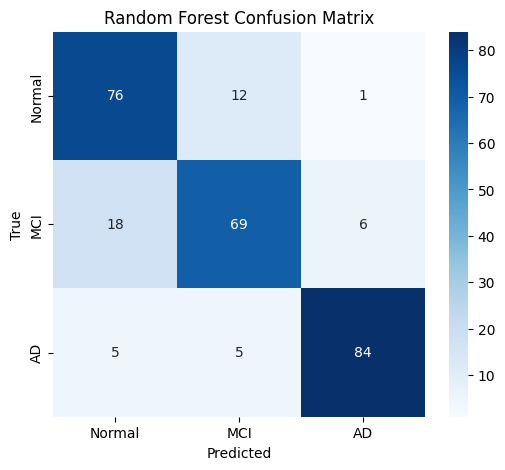

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ✅ Flatten the EEG input for scikit-learn models (samples, 10, 200) → (samples, 2000)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# 🌲 Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_flat, y_train)

# 🔍 Predict and Evaluate
y_pred = rf.predict(X_test_flat)
acc = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred, average='macro')
cm = confusion_matrix(y_test, y_pred)

# 📊 Print Metrics and Confusion Matrix
print(f"🌲 Random Forest - Accuracy: {acc:.4f}, Recall: {recall:.4f}")
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'MCI', 'AD'], yticklabels=['Normal', 'MCI', 'AD'])
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
